## Simulating a complete set of data (calibration + science) for testing the DRP

In [1]:
from copy import deepcopy

import numpy as np
import astropy.units as u
import scopesim as sim
import scopesim_templates as sim_tp

from zs_scopesim_tools.helpers import (disable_scopesim_top_level_catch, warning_prevent_sync_alt_ra_dec, ignore_warnings,
                                       set_scopesim_log_level, make_local_output_dir, configure_irdb_path,
                                       list_effects, simulate, save_zshooter_readout)

configure_irdb_path()  ## tried to make it run automatically in bootstrap_env but didn't work, should find a way though
# set up log toggels
set_scopesim_log_level("warning")
disable_scopesim_top_level_catch()
ignore_warnings()

# set up output directory
output_dir = make_local_output_dir(dirname="sims")

In [2]:
# load instrument configs
cmd = sim.UserCommands(use_instrument="ZShooter_v2", set_modes=["SPEC"])

In [3]:
# display list of effects
df = list_effects(cmd)
df

,included,effect,class,config,selector,data file
0,True,atmo_transmission,TERCurve,MaunaKea (ATMO),,TER_maunakea_tapas.dat
1,True,continuum_emission,SkyBackgroundTERCurve,MaunaKea (ATMO),,
2,True,airglow_and_interline_continuum,PalaceAirglowEmission,MaunaKea (ATMO),,
3,True,seeing_psf,AOEnhanceablePSF,MaunaKea (ATMO),,
4,True,adc_residuals,ADCShift,MaunaKea (ATMO),,adc_residuals.dat
5,True,telescope_reflection,SurfaceList,keck (TEL),,LIST_keck_mirrors.dat
6,True,dichroic_tree,DichroicTree,ZShooter (INST),,
7,True,slitwheel_selector,SelectorWheel,ZShooter (INST),,
8,True,channel_optics_selector,SelectorWheel,ZShooter (INST),,
9,False,ir_blocking_filter_selector,SelectorWheel,ZShooter (INST),,


### Create sources

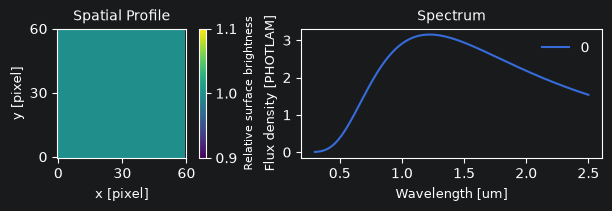

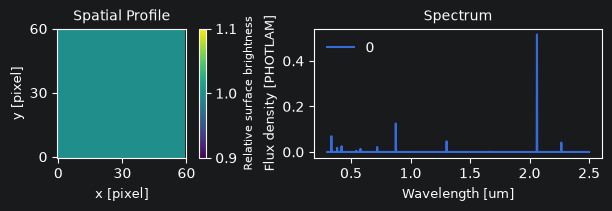

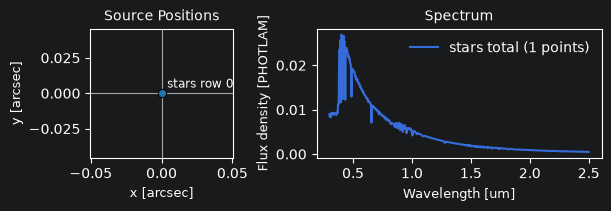

In [4]:
# create flat source
domeflat = sim_tp.calibration.flat_field(temperature=3000*u.K, amplitude=8*u.ABmag, filter_curve='V', extend=60)
# create arc source
from zs_scopesim_tools.sources import lamp_flat
lamp = lamp_flat(scale_amplitude=1e-5)
# create science source
star = sim_tp.star(filter_name='V', amplitude=12*u.ABmag)

from zs_scopesim_tools.plots import PlotScene
plotter = PlotScene()
_ = plotter.from_source(domeflat)
_ = plotter.from_source(lamp)
_ = plotter.from_source(star)

 I have defined a dictionary of exposures to make it easier to loop through simulations with different properties (a.k.a. values of the keys in cmd dict like !OBS.dit_blue, !OBS.airmass, etc.). The keys of this dictionary are target names, the values are nested dicts with two keys: "props" - containing all the properties to update in cmd, and "source" - containing the source object to simulate.

In [5]:
exposures = {"domeflat": {"props": {"!OBS.dit_blue": 60, "!OBS.dit_green": 5, "!OBS.dit_red": 1,
                                    "!OBS.dit_yj": 1, "!OBS.dit_h": 1, "!OBS.dit_k": 1,
                                    "!OBS.ndit_blue": 1, "!OBS.ndit_green": 1, "!OBS.ndit_red": 1,
                                    "!OBS.ndit_yj": 1, "!OBS.ndit_h": 1, "!OBS.ndit_k": 1},
                          "source": domeflat},
             "arcs": {"props": {"!OBS.dit_blue": 20, "!OBS.dit_green": 10, "!OBS.dit_red": 3,
                                    "!OBS.dit_yj": 3, "!OBS.dit_h": 10, "!OBS.dit_k": 10,
                                    "!OBS.ndit_blue": 1, "!OBS.ndit_green": 1, "!OBS.ndit_red": 1,
                                    "!OBS.ndit_yj": 1, "!OBS.ndit_h": 1, "!OBS.ndit_k": 1},
                      "source": lamp},
             "bias": {"props": {"!OBS.dit_blue": 0, "!OBS.dit_green": 0, "!OBS.dit_red": 0,
                                    "!OBS.dit_yj": 0, "!OBS.dit_h": 0, "!OBS.dit_k": 0,
                                    "!OBS.ndit_blue": 1, "!OBS.ndit_green": 1, "!OBS.ndit_red": 1,
                                    "!OBS.ndit_yj": 1, "!OBS.ndit_h": 1, "!OBS.ndit_k": 1},
                      "source": None},
             "star": {"props": {"!OBS.dit_blue": 300, "!OBS.dit_green": 300, "!OBS.dit_red": 300,
                                    "!OBS.dit_yj": 300, "!OBS.dit_h": 300, "!OBS.dit_k": 300,
                                    "!OBS.ndit_blue": 1, "!OBS.ndit_green": 1, "!OBS.ndit_red": 1,
                                    "!OBS.ndit_yj": 1, "!OBS.ndit_h": 1, "!OBS.ndit_k": 1},
                      "source": star}}

### Simulate calibration sources

In [7]:
from zs_scopesim_tools.helpers import simulate
# disable all sky effects
disable_effects = ["atmo_transmission", "continuum_emission", "airglow_and_interline_continuum",
                   "seeing_psf", "adc_residuals"]

rawsims = {}
for obj in ["domeflat", "arcs", "bias"]:
    val = exposures[obj]
    print(f"Simulating {obj}...")
    # update any cmd keys for this exposure
    cmd.update_alias(cmd, val["props"])
    zs, hdul = simulate(cmd, source=val["source"], disable_effects=disable_effects, hide_progress_bars=True)
    # check desired counts
    print(f'Max counts: {[np.max(hdu[1].data) for hdu in hdul]}')
    rawsims[obj] = hdul


Simulating domeflat...
astar.scopesim.effects.sky_ter_curves - WARNING: wmin 299.99999999999994 is below the minimum wavelength covered by SkyCalc. Setting to 300 nm.
Max counts: [np.float64(20671.113789986463), np.float64(21640.999183729167), np.float64(17358.09411772858), np.float64(23207.44239527744), np.float64(25855.88736161765), np.float64(24425.660040147653)]
Simulating arcs...
astar.scopesim.effects.sky_ter_curves - WARNING: wmin 299.99999999999994 is below the minimum wavelength covered by SkyCalc. Setting to 300 nm.
Max counts: [np.float64(20645.985713899663), np.float64(10121.967137947911), np.float64(20275.15599307605), np.float64(20794.798600655424), np.float64(18279.358814885192), np.float64(29291.160086778138)]
Simulating bias...
astar.scopesim.effects.sky_ter_curves - WARNING: wmin 299.99999999999994 is below the minimum wavelength covered by SkyCalc. Setting to 300 nm.
Max counts: [np.float64(1040.5155935598368), np.float64(1040.5155935598368), np.float64(1040.51559355

In [8]:
hdul # list of HDULists, =len(channels) = 6, each HDUList has 2 HDUs: [0] primary, [1] image

[[<astropy.io.fits.hdu.image.PrimaryHDU object at 0x11bf75010>, <astropy.io.fits.hdu.image.ImageHDU object at 0x11c2b37d0>],
 [<astropy.io.fits.hdu.image.PrimaryHDU object at 0x1234abb30>, <astropy.io.fits.hdu.image.ImageHDU object at 0x1234a8440>],
 [<astropy.io.fits.hdu.image.PrimaryHDU object at 0x11c329af0>, <astropy.io.fits.hdu.image.ImageHDU object at 0x11c32b350>],
 [<astropy.io.fits.hdu.image.PrimaryHDU object at 0x11c3286b0>, <astropy.io.fits.hdu.image.ImageHDU object at 0x11c329550>],
 [<astropy.io.fits.hdu.image.PrimaryHDU object at 0x11c328d10>, <astropy.io.fits.hdu.image.ImageHDU object at 0x11c3286e0>],
 [<astropy.io.fits.hdu.image.PrimaryHDU object at 0x11be12870>, <astropy.io.fits.hdu.image.ImageHDU object at 0x11c636930>]]

Save the simulated data. The helper function can add cmd keys/values as extra header keywords to the FITS files for later reference before saving.

In [9]:
from zs_scopesim_tools.helpers import save_zshooter_readout

for obj in ["domeflat", "arcs", "bias"]:
    _ = save_zshooter_readout(rawsims[obj], output_dir=output_dir, filename_prefix=obj, imagetype=obj.upper(), cmds=cmd, train=zs)

### Simulate science sources

With full sky background and all effects enabled

In [10]:
val = exposures["star"]

# update any cmd keys for this exposure
cmd.update_alias(cmd, val["props"])
zs, hdul = simulate(cmd, source=val["source"], hide_progress_bars=True)
# check desired counts
print(f'Max counts: {[np.max(hdu[1].data) for hdu in hdul]}')
save_zshooter_readout(hdul, output_dir=output_dir, filename_prefix="star_sky", imagetype="STAR_SKY", cmds=cmd, train=zs)
rawsims["star_sky"] = hdul

astar.scopesim.effects.sky_ter_curves - WARNING: wmin 299.99999999999994 is below the minimum wavelength covered by SkyCalc. Setting to 300 nm.
Max counts: [np.float64(14333.906278600076), np.float64(16046.108324534069), np.float64(14203.08109594559), np.float64(19956.530461797807), np.float64(74321.35495801433), np.float64(41903.40650697901)]


Only sky background, no source, but same exposure time as the science source

In [11]:
val = exposures["star"]

# update any cmd keys for this exposure
cmd.update_alias(cmd, val["props"])
zs, hdul = simulate(cmd, source=None, hide_progress_bars=True)
# check desired counts
print(f'Max counts: {[np.max(hdu[1].data) for hdu in hdul]}')
rawsims["sky"] = hdul
save_zshooter_readout(hdul, output_dir=output_dir, filename_prefix="sky", imagetype="SKY", cmds=cmd, train=zs)

# subtract sky from source+sky and save
sub_hdul = []
for i,hdu in enumerate(hdul):
    sub_hdu = deepcopy(hdu)
    source_data = rawsims["star_sky"][i][1].data
    sky_data = hdu[1].data
    sub_hdu[1].data = source_data - sky_data
    sub_hdul.append(sub_hdu)
save_zshooter_readout(sub_hdul, output_dir=output_dir, filename_prefix="star_subsky", imagetype="STAR_SUBSKY", cmds=cmd, train=zs)
rawsims["star_subsky"] = sub_hdul

astar.scopesim.effects.sky_ter_curves - WARNING: wmin 299.99999999999994 is below the minimum wavelength covered by SkyCalc. Setting to 300 nm.
Max counts: [np.float64(1047.19773009891), np.float64(1913.0448691332558), np.float64(3085.0713598707407), np.float64(13527.004951531228), np.float64(70236.3484887996), np.float64(38072.166287808745)]


With sky background disabled

In [12]:
val = exposures["star"]

# update any cmd keys for this exposure
cmd.update_alias(cmd, val["props"])
zs, hdul = simulate(cmd, source=val["source"], disable_backgrounds="sky", hide_progress_bars=True)
# check desired counts
print(f'Max counts: {[np.max(hdu[1].data) for hdu in hdul]}')
save_zshooter_readout(hdul, output_dir=output_dir, filename_prefix="star_nosky", imagetype="STAR_NOSKY", cmds=cmd, train=zs)
rawsims["star_nosky"] = hdul

astar.scopesim.effects.sky_ter_curves - WARNING: wmin 299.99999999999994 is below the minimum wavelength covered by SkyCalc. Setting to 300 nm.
Max counts: [np.float64(14339.075195153038), np.float64(16134.11989006631), np.float64(14409.011459803405), np.float64(11210.477438889144), np.float64(7333.586801925581), np.float64(5018.1726301499075)]


[PosixPath('/Users/yashvi/Desktop/ZShooter/zs-scopesim/dev_notebooks/sims/star_nosky_BLUE.fits'),
 PosixPath('/Users/yashvi/Desktop/ZShooter/zs-scopesim/dev_notebooks/sims/star_nosky_GREEN.fits'),
 PosixPath('/Users/yashvi/Desktop/ZShooter/zs-scopesim/dev_notebooks/sims/star_nosky_RED.fits'),
 PosixPath('/Users/yashvi/Desktop/ZShooter/zs-scopesim/dev_notebooks/sims/star_nosky_YJ.fits'),
 PosixPath('/Users/yashvi/Desktop/ZShooter/zs-scopesim/dev_notebooks/sims/star_nosky_H.fits'),
 PosixPath('/Users/yashvi/Desktop/ZShooter/zs-scopesim/dev_notebooks/sims/star_nosky_K.fits')]